# Imports

In [2]:
%matplotlib inline

import os
import pickle
import re
import shutil
import sys
sys.path.append(os.path.dirname(os.path.dirname(os.getcwd())))
from itertools import product
from scipy.stats import norm
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yaml
import time
from matplotlib.backends.backend_pdf import PdfPages
from analyze.tools import load_npy, load_yaml_as_df, load_pkl, exist_metric, exist_stf_metric, inverse_stf_metrics, keep_split, is_full_group, set_seed, timing_decorator
from utils.fft_ot import cal_wasserstein
from exp.exp_long_term_forecasting_meta_ml3 import CovarianceMatrix
import json

plt.style.use('default')
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
plt.rc('font', family='Arial')
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.size'] = 10

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# complexity of meta

In [17]:
import torch
import torch.nn as nn
from types import SimpleNamespace
from torch.func import functional_call

sl = 96
trys = 100
device = 'cuda:0'
batch_size = 128
d = 21   # Weather
sl = 96

os.environ['CUDA_VISIBLE_DEVICES'] = '0'

criterion = nn.MSELoss()

class MLP(nn.Module):
    def __init__(self, input_size=96, hidden_size=128, output_size=96):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = x.transpose(1, 2)
        x = self.fc1(x)
        x = torch.relu(x)
        x = self.fc2(x)
        return x.transpose(1, 2)


def get_param_dict(module):
    # 返回 OrderedDict，适用于 functional forward
    return dict(module.named_parameters())


def update_param_dict(param_dict, grads_dict, lr):
    """
    使用梯度字典更新参数字典。
    grads_dict 仅包含有梯度的参数，其他参数视为 grad=0（保持不变）。
    """
    updated_params = {}
    for k, v in param_dict.items():
        if k in grads_dict and grads_dict[k] is not None:
            updated_params[k] = v - lr * grads_dict[k]
        else:
            # 该参数无梯度 → 视为梯度为 0 → 不更新
            updated_params[k] = v  # 保持原参数，等价于 +0
    return updated_params


def test_time(pl, mode):
    set_seed(2023)

    model = MLP(input_size=sl, hidden_size=128, output_size=pl).to(device)
    args = SimpleNamespace(
        pred_len=pl,
        auxi_loss='MSE',
        reg_lambda=0.
    )
    A = CovarianceMatrix(args).to(device)
    batch_xs = [torch.randn(batch_size, sl, d, device=device).float() for i in range(3*2)]
    batch_ys = [torch.randn(batch_size, pl, d, device=device).float() for i in range(3*2)]

    # 时间统计变量
    model_forward_time = 0
    A_forward_time = 0
    model_backward_time = 0
    A_backward_time = 0

    total_loss = 0
    for i in range(3):
        # inner steps = 1
        params = {k: v.clone() for k, v in model.named_parameters()}
        
        # Model forward - inner step
        start_time = time.time()
        outputs = functional_call(model, params, tuple([batch_xs[i]]))
        model_forward_time += time.time() - start_time
        
        # A forward - inner step  
        start_time = time.time()
        loss = A.get_loss(outputs, batch_ys[i])
        A_forward_time += time.time() - start_time
        
        # Model backward - inner step
        start_time = time.time()
        model_grads = torch.autograd.grad(loss, params.values(), create_graph=False)
        model_backward_time += time.time() - start_time
        
        model_grads_dict = {key: value for key, value in zip(params.keys(), model_grads)}
        params = update_param_dict(params, model_grads_dict, lr=0.002)

        # Model forward - query step
        start_time = time.time()
        outputs = functional_call(model, params, tuple([batch_xs[i+3]]))
        model_forward_time += time.time() - start_time
        
        # A forward - query step
        start_time = time.time()
        meta_loss = A.get_loss(outputs, batch_ys[i+3])
        A_forward_time += time.time() - start_time
        
        total_loss += meta_loss
        
    # meta step
    total_loss /= 3
    
    # A backward - meta step
    start_time = time.time()
    total_loss.backward()
    A_backward_time += time.time() - start_time

    return {
        'model_forward_time': model_forward_time * 1000,
        'A_forward_time': A_forward_time * 1000, 
        'model_backward_time': model_backward_time * 1000,
        'A_backward_time': A_backward_time * 1000
    }


def collect_data(trials, test_params):
    results = []
    for pl, mode in test_params:
        for _ in range(trials):
            total_times = test_time(pl, mode)
            total_times.update({'pred_len': pl, 'mode': mode})
            results.append(total_times)  # Convert to milliseconds
    return pd.DataFrame(results)


def remove_extreme_samples(group):
    threshold = 20
    if len(group) <= threshold:
        return pd.DataFrame(columns=group.columns)
    return group.nlargest(len(group) - threshold, 'time').nsmallest(len(group) - threshold, 'time')


trials = 100

test_params = list(product([6, 12, 24, 32, 48, 64, 96, 128, 192, 256, 336, 512, 720, 1024, 1440, 2048], ["QDF"]))
data = collect_data(trials, test_params)

save_root = '/mnt/tidalfs-bdsz01/usr/panlicheng/workspace/ProjDF-Meta/stats_ML3'

dfs = []
for tag in ['model_forward_time', 'A_forward_time', 'model_backward_time', 'A_backward_time']:
    data_ = data[['pred_len', 'mode', tag]].copy()
    data_.columns = ['pred_len', 'mode', 'time']
    data_ = data_.groupby(['pred_len', 'mode']).apply(remove_extreme_samples).reset_index(drop=True)
    data_.to_csv(os.path.join(save_root, f'qdf_{tag}.csv'), index=False)
    dfs.append(data_)

df = pd.concat(dfs, axis=1)


# plot

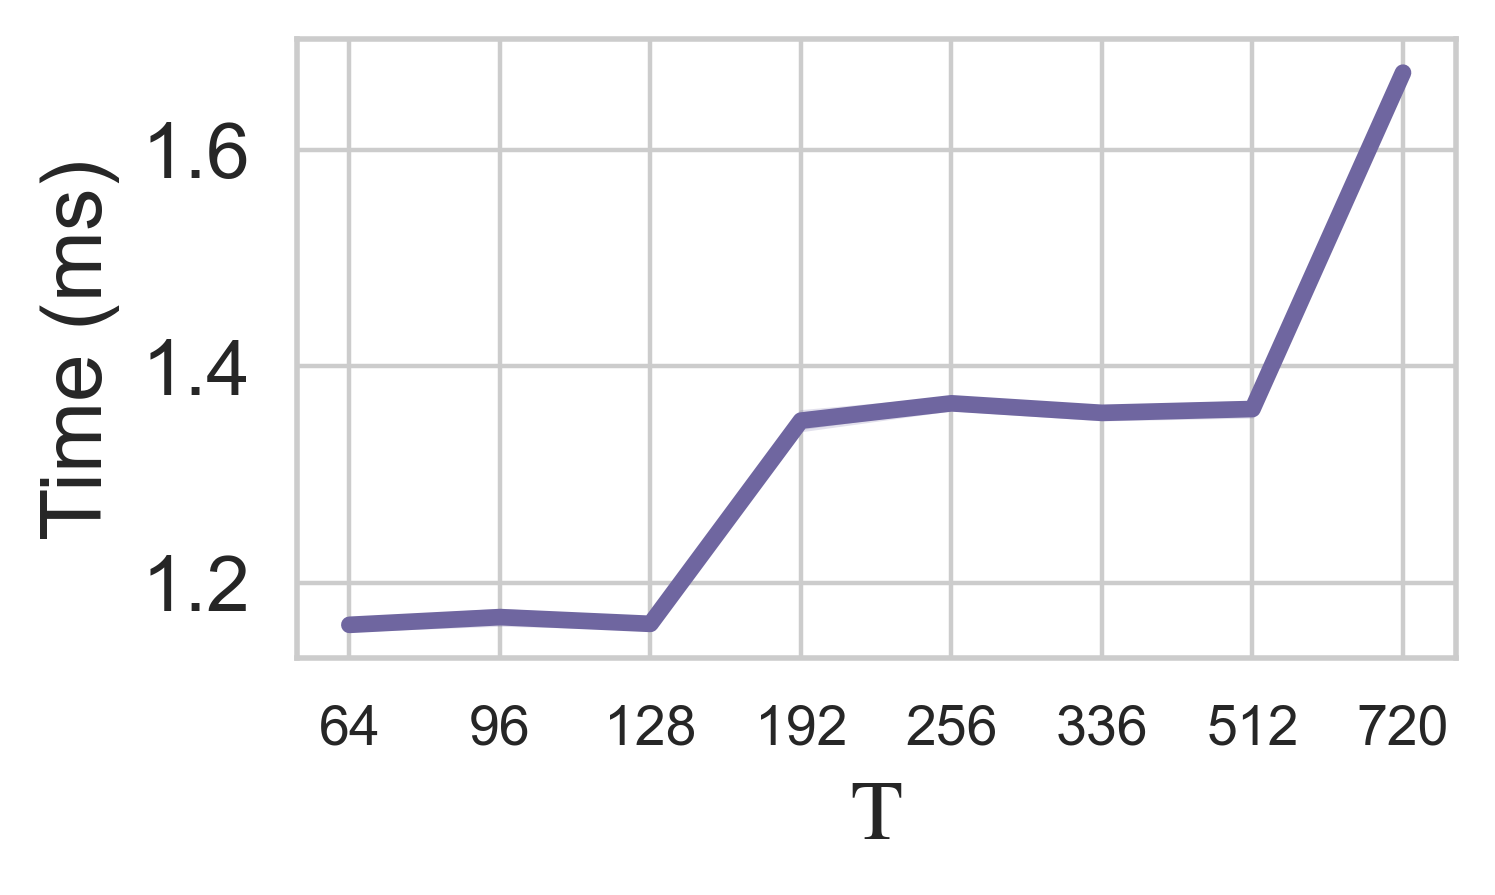

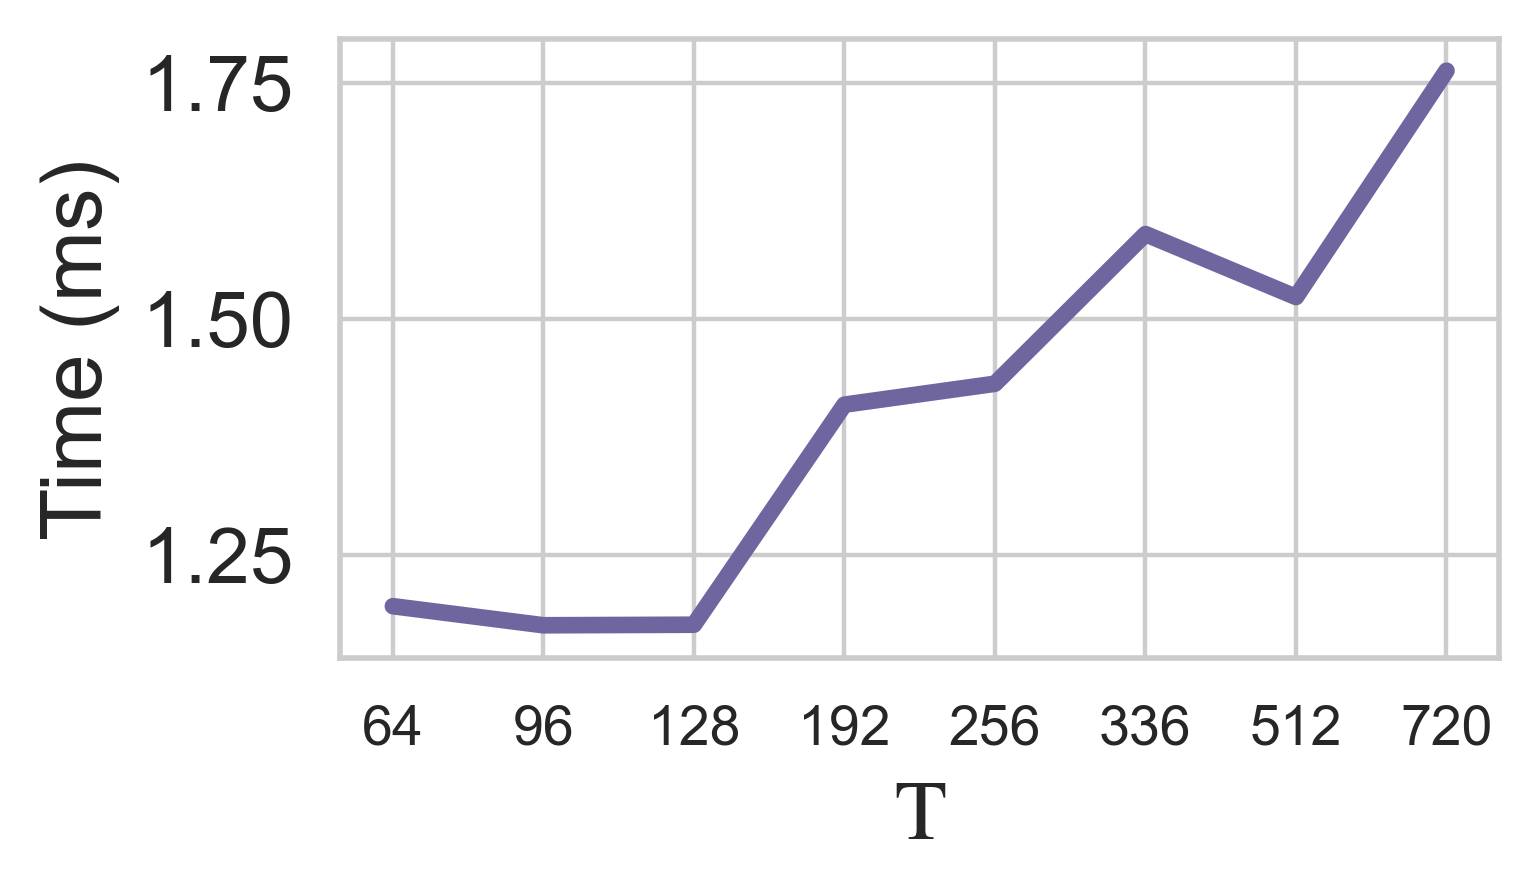

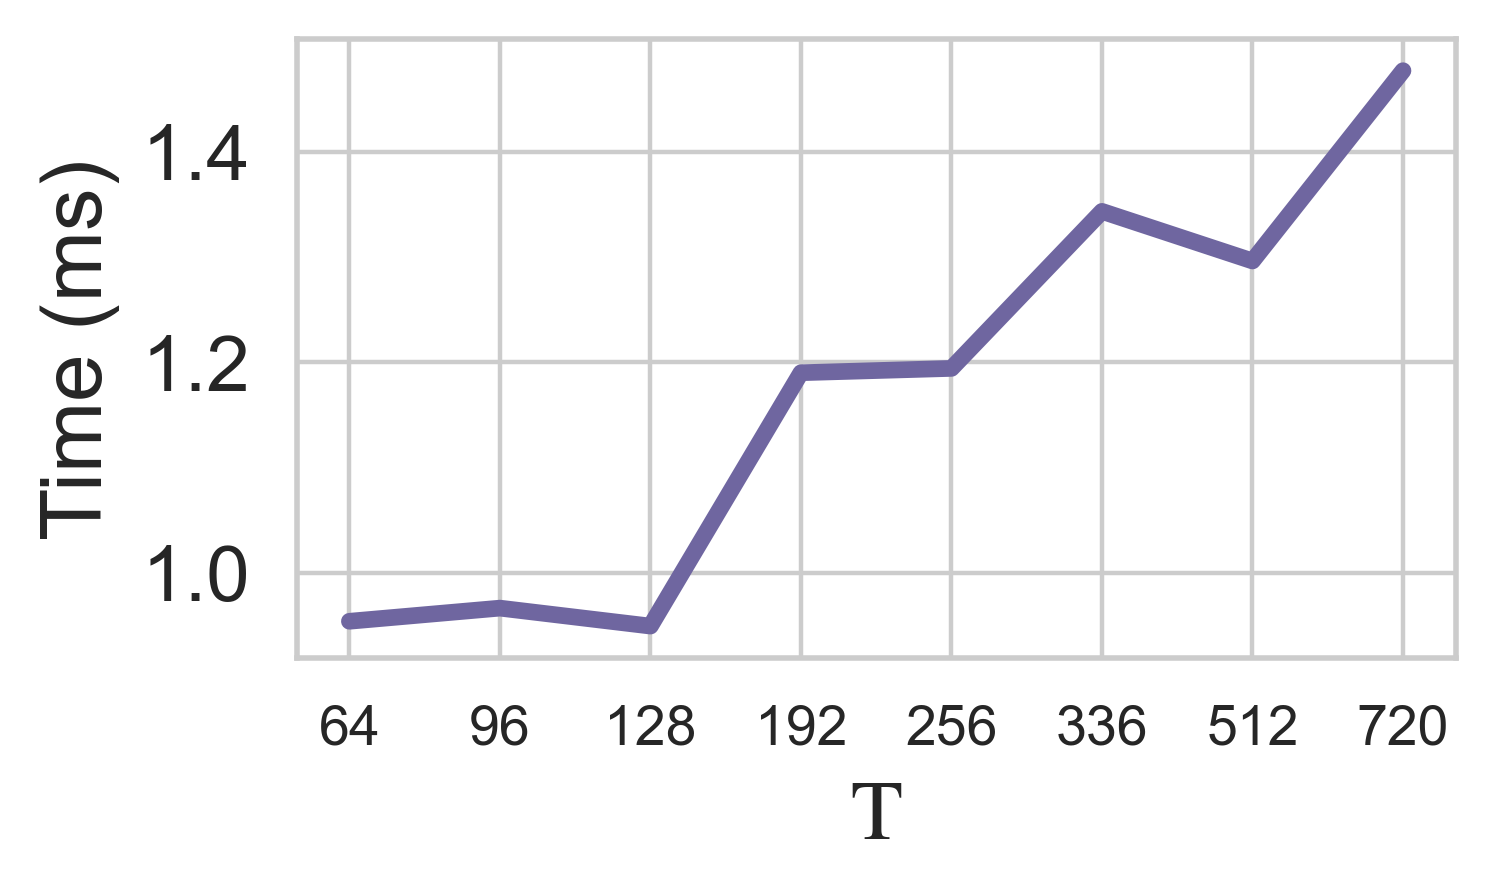

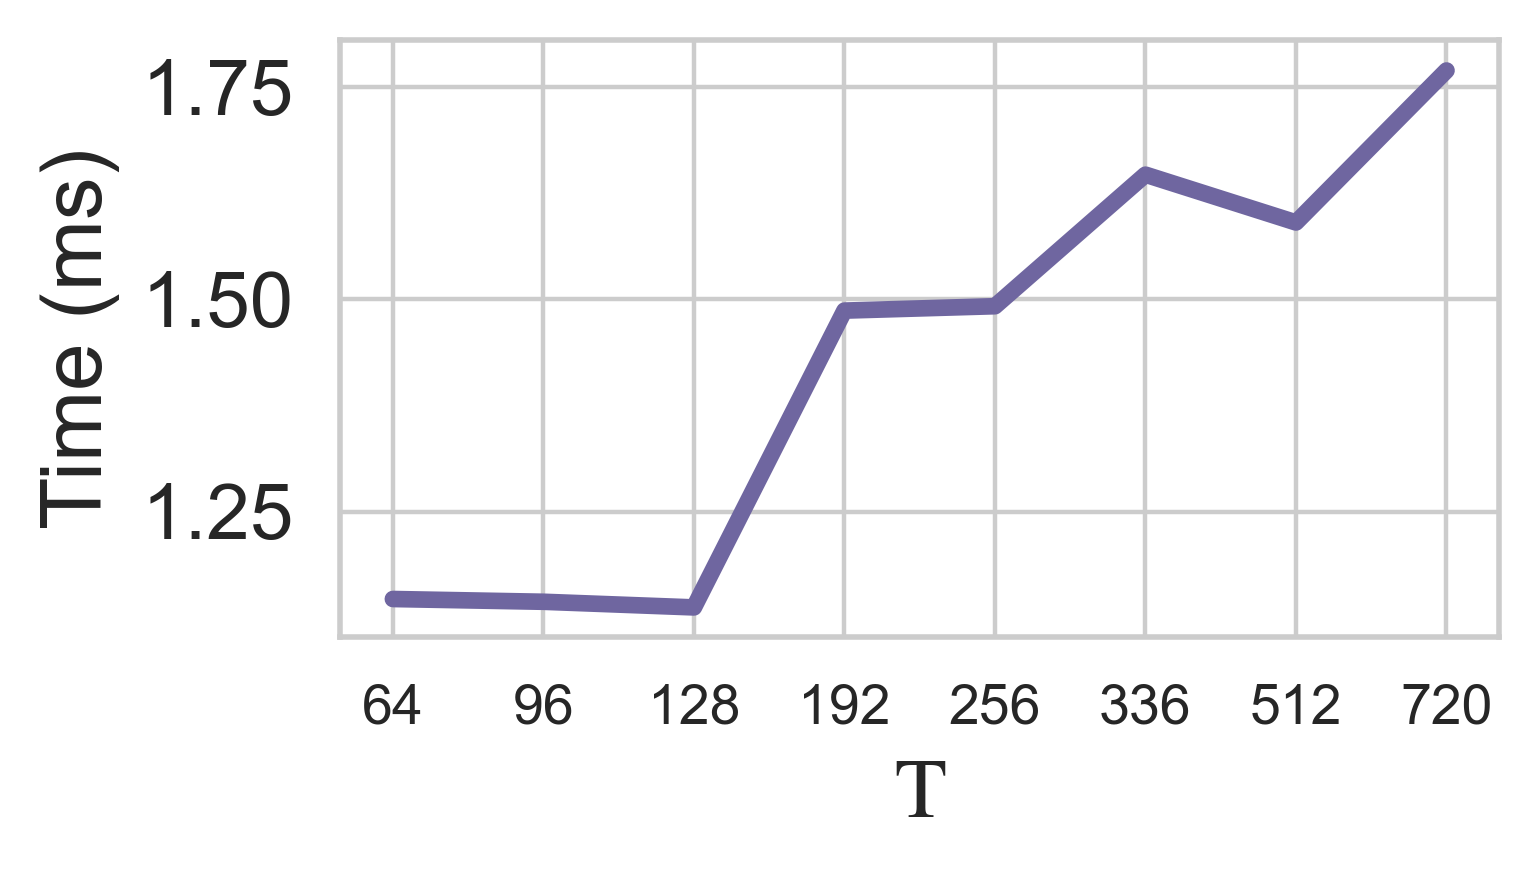

In [22]:
def plot(dataset, figure_name='figure', x='labda', x_name=r'$\lambda$', hue='p_noise', ytick1=None, ytick2=None, ypad1=None, ypad2=None, loc='upper left', xtick1=None):
    style = ['darkgrid', 'dark', 'white', 'whitegrid', 'ticks']
    context = ['paper', 'notebook', 'talk', 'poster']
    # palette = sns.color_palette('deep')
    palette = sns.color_palette('Purples_d')
    palette = [palette[3], palette[0], palette[2]] + palette[4:]
    sns.set_theme(style=style[3], context=context[0], font='Arial', font_scale=1.6, palette=[palette[0], palette[3], palette[2]] + palette[4:])

    # dataset = dataset.sort_values(by=x)
    # dataset[x] = dataset[x].astype(str)

    f = plt.figure(dpi=400, figsize=(4,2.5)) # 如果只画一条线，就用红色，高改为3->2.5
    f.subplots_adjust(top=0.9, left=0.1, right=0.9, bottom=0.2)
    f.add_subplot(1,1,1)
    sns.lineplot(x=x, y='time', data=dataset, errorbar=('ci', 99.9), markers=['s', 'o', "P", "*"], linewidth=3, markersize=8, markeredgecolor='k', palette="Purples_d")

    ax = plt.gca()
    # handles, labels = plt.gca().get_legend_handles_labels()
    # ol=1, loc=loc)
    # plt.legend(handles=handles, ncol=2, loc=legend_location)
    if ytick1:
        plt.yticks(ytick1)
    if xtick1:
        plt.xticks(xtick1)
    if ypad1:
        ax.yaxis.set_major_locator(plt.MultipleLocator(ypad1))  # 小数点后3位数间隔。
    plt.tick_params(axis='x', labelsize=10)
    plt.ylabel('Time (ms)')
    plt.xlabel(x_name)
    plt.tight_layout()
    with PdfPages(f"{figure_name}.pdf") as pdf:
        pdf.savefig(f, bbox_inches='tight', pad_inches=0.01)
    # plt.show()

save_root = '/mnt/tidalfs-bdsz01/usr/panlicheng/workspace/ProjDF-Meta/figure_ML3'
os.makedirs(f"{save_root}/timing", exist_ok=True)

stats_root = '/mnt/tidalfs-bdsz01/usr/panlicheng/workspace/ProjDF-Meta/stats_ML3'

pls = [64, 96, 128, 192, 256, 336, 512, 720]

for tag in ['model_forward_time', 'A_forward_time', 'model_backward_time', 'A_backward_time']:
    # tag = 'model_forward_time'
    data = pd.read_csv(os.path.join(stats_root, f'qdf_{tag}.csv'))
    data = data[data.pred_len.isin(pls)]

    N = 50
    df1 = data.copy()
    df1 = df1.groupby(['pred_len']).head(N).reset_index(drop=True)
    df1['pred_len'] = df1['pred_len'].astype(str)

    save_name = f"{save_root}/timing/{tag}"
    plot(df1, x='pred_len', figure_name=save_name, x_name=r"$\mathrm{T}$", xtick1=[str(pl) for pl in pls])

In [108]:

data_f = pd.read_csv(os.path.join(save_root, f'distdf_forward.csv'))
data_f = data_f[data_f.pred_len.isin([12, 24, 32, 48, 64, 96, 128, 192, 256, 336, 512, 720, 1024, 1440])]
data_b = pd.read_csv(os.path.join(save_root, f'distdf_backward.csv'))
data_b = data_b[data_b.pred_len.isin([12, 24, 32, 48, 64, 96, 128, 192, 256, 336, 512, 720, 1024, 1440])]

N = 60
df1 = data_f.groupby(['pred_len', 'mode']).head(N).reset_index(drop=True)
agg = df1.groupby(['pred_len', 'mode'])['time'].agg(['mean', 'std']).reset_index()
agg['result'] = agg['mean'].map(lambda x: f"{x:.3f}") + '±' + agg['std'].map(lambda x: f"{x:.3f}")
pivot1 = agg.pivot(index='mode', columns='pred_len', values='result')

df2 = data_b.groupby(['pred_len', 'mode']).head(N).reset_index(drop=True)
agg = df2.groupby(['pred_len', 'mode'])['time'].agg(['mean', 'std']).reset_index()
agg['result'] = agg['mean'].map(lambda x: f"{x:.3f}") + '±' + agg['std'].map(lambda x: f"{x:.3f}")
pivot2 = agg.pivot(index='mode', columns='pred_len', values='result')

pivot1['direction'] = 'forward'
pivot2['direction'] = 'backward'

pivot1 = pivot1.reset_index().set_index(['direction', 'mode'])
pivot2 = pivot2.reset_index().set_index(['direction', 'mode'])

pivot = pd.concat([pivot1, pivot2])
pivot

pred_len                   12           24           32           48  \
direction mode                                                         
forward   DF      0.035±0.001  0.035±0.001  0.034±0.001  0.034±0.001   
          DistDF  0.749±0.003  0.750±0.004  0.751±0.005  0.731±0.004   
backward  DF      0.066±0.004  0.066±0.004  0.066±0.003  0.066±0.003   
          DistDF  0.584±0.006  0.584±0.005  0.578±0.005  0.580±0.006   

pred_len                   64           96          128          192  \
direction mode                                                         
forward   DF      0.035±0.001  0.034±0.001  0.035±0.001  0.035±0.001   
          DistDF  0.729±0.004  0.730±0.005  0.719±0.004  0.735±0.004   
backward  DF      0.065±0.003  0.066±0.004  0.065±0.004  0.067±0.004   
          DistDF  0.580±0.004  0.580±0.004  0.578±0.005  0.580±0.006   

pred_len                  256          336          512          720  \
direction mode                                                         
forward   DF      0.040±0.001  0.040±0.001  0.040±0.001  0.039±0.001   
          DistDF  0.722±0.005  0.767±0.004  0.766±0.005  0.765±0.004   
backward  DF      0.066±0.004  0.067±0.004  0.066±0.003  0.065±0.003   
          DistDF  0.576±0.006  0.609±0.006  0.608±0.006  0.620±0.007   

pred_len                 1024         1440  
direction mode                              
forward   DF      0.039±0.001  0.039±0.001  
          DistDF  0.766±0.005  0.788±0.007  
backward  DF      0.067±0.003  0.067±0.003  
          DistDF  0.612±0.006  1.349±0.231

In [127]:
contents = pivot.to_latex()
print(contents)

\begin{tabular}{llllllllllllllll}
\toprule
 & pred_len & 12 & 24 & 32 & 48 & 64 & 96 & 128 & 192 & 256 & 336 & 512 & 720 & 1024 & 1440 \\
direction & mode &  &  &  &  &  &  &  &  &  &  &  &  &  &  \\
\midrule
\multirow[t]{2}{*}{forward} & DF & 0.035±0.001 & 0.035±0.001 & 0.034±0.001 & 0.034±0.001 & 0.035±0.001 & 0.034±0.001 & 0.035±0.001 & 0.035±0.001 & 0.040±0.001 & 0.040±0.001 & 0.040±0.001 & 0.039±0.001 & 0.039±0.001 & 0.039±0.001 \\
 & DistDF & 0.749±0.003 & 0.750±0.004 & 0.751±0.005 & 0.731±0.004 & 0.729±0.004 & 0.730±0.005 & 0.719±0.004 & 0.735±0.004 & 0.722±0.005 & 0.767±0.004 & 0.766±0.005 & 0.765±0.004 & 0.766±0.005 & 0.788±0.007 \\
\cline{1-16}
\multirow[t]{2}{*}{backward} & DF & 0.066±0.004 & 0.066±0.004 & 0.066±0.003 & 0.066±0.003 & 0.065±0.003 & 0.066±0.004 & 0.065±0.004 & 0.067±0.004 & 0.066±0.004 & 0.067±0.004 & 0.066±0.003 & 0.065±0.003 & 0.067±0.003 & 0.067±0.003 \\
 & DistDF & 0.584±0.006 & 0.584±0.005 & 0.578±0.005 & 0.580±0.006 & 0.580±0.004 & 0.580±0.004 & 0.578±0.

# plot

/tmp/ipykernel_904517/2795429446.py:15: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(x=x, y='time', data=dataset, errorbar=('ci', 99.9), markers=['s', 'o', "P", "*"], linewidth=3, markersize=8, markeredgecolor='k', palette="Purples_d")


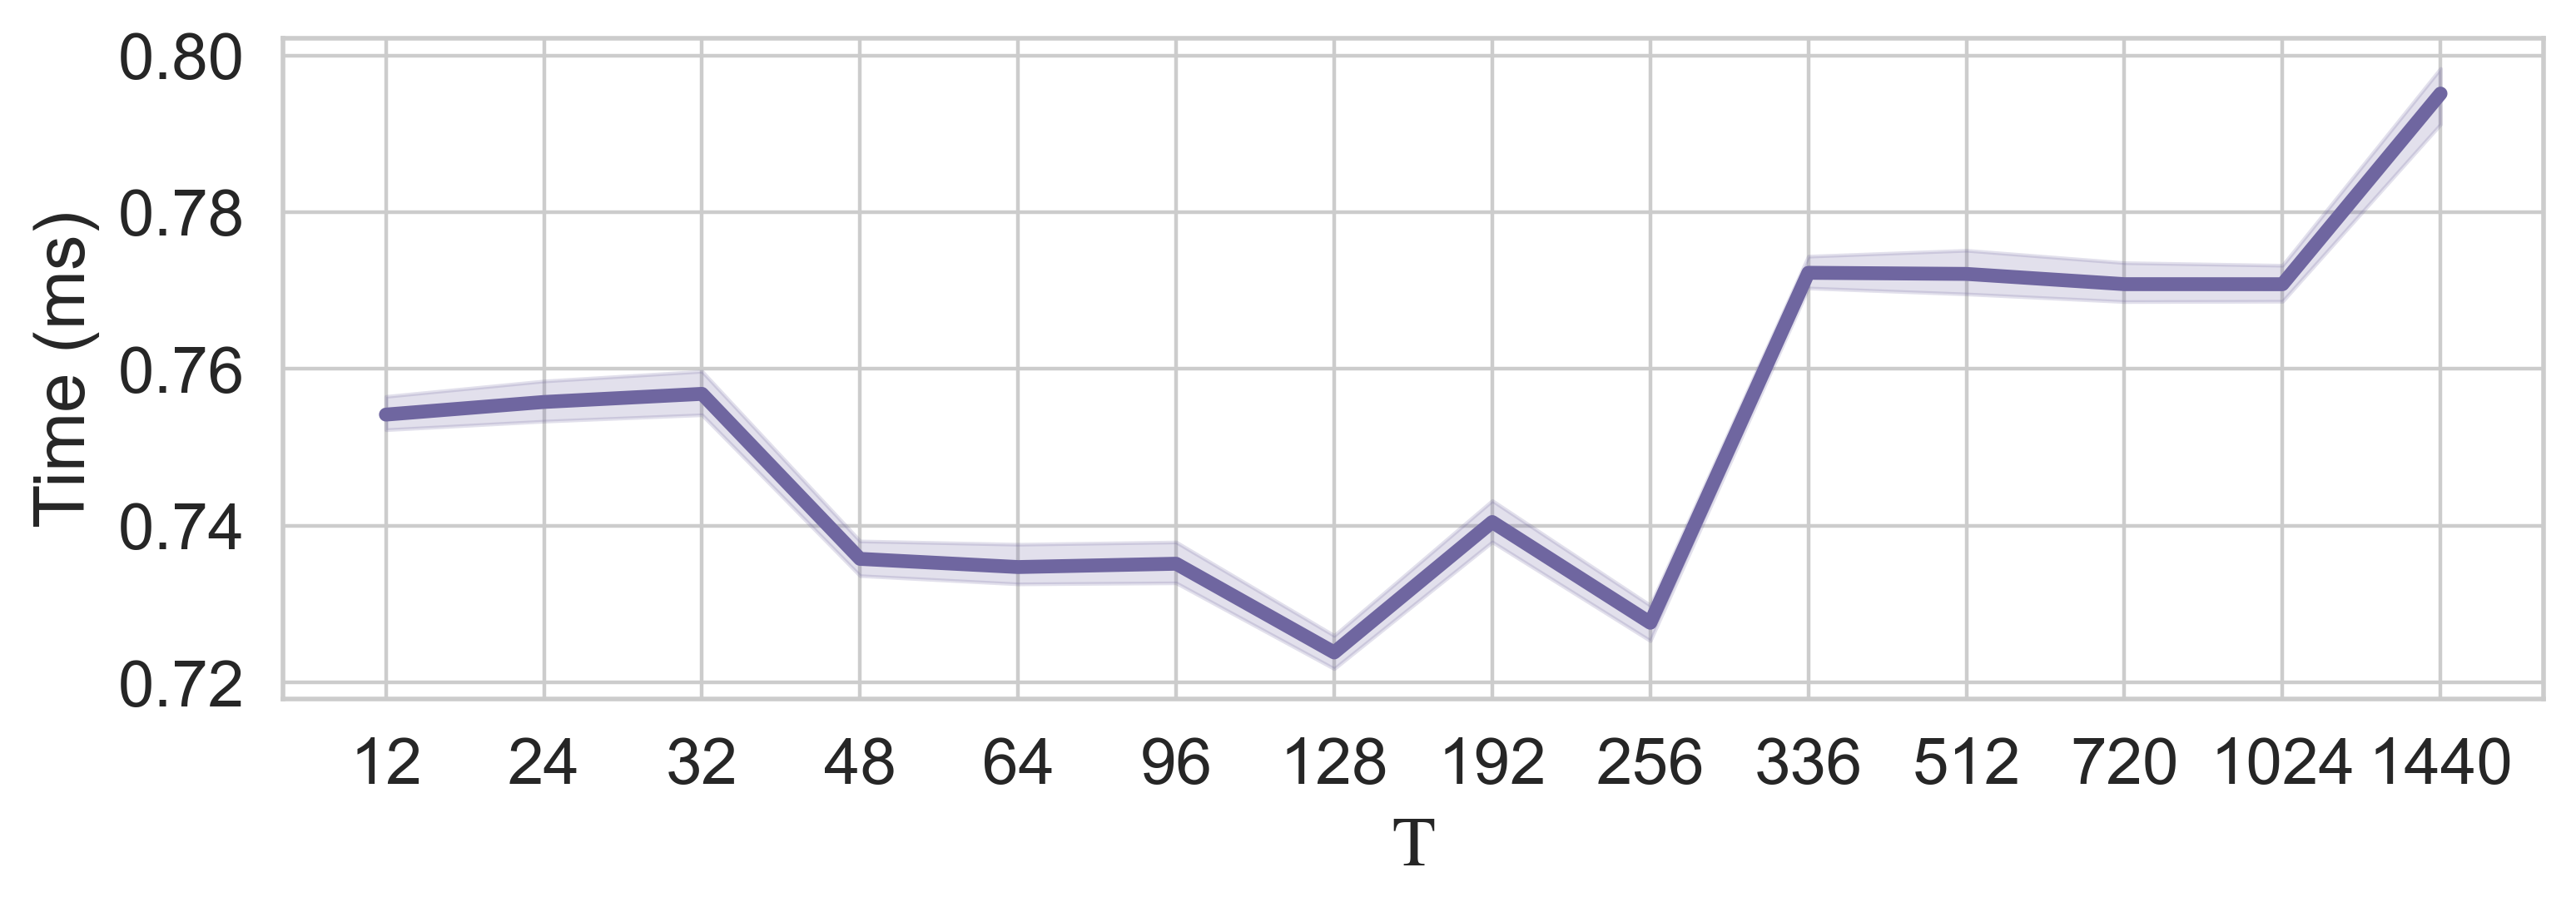

In [126]:
def plot(dataset, figure_name='figure', x='labda', x_name=r'$\lambda$', hue='p_noise', ytick1=None, ytick2=None, ypad1=None, ypad2=None, loc='upper left', xtick1=None):
    style = ['darkgrid', 'dark', 'white', 'whitegrid', 'ticks']
    context = ['paper', 'notebook', 'talk', 'poster']
    # palette = sns.color_palette('deep')
    palette = sns.color_palette('Purples_d')
    palette = [palette[3], palette[0], palette[2]] + palette[4:]
    sns.set_theme(style=style[3], context=context[0], font='Arial', font_scale=1.6, palette=[palette[0], palette[3], palette[2]] + palette[4:])

    # dataset = dataset.sort_values(by=x)
    # dataset[x] = dataset[x].astype(str)

    f = plt.figure(dpi=400, figsize=(8,3)) # 如果只画一条线，就用红色，高改为3->2.5
    f.subplots_adjust(top=0.9, left=0.1, right=0.9, bottom=0.2)
    f.add_subplot(1,1,1)
    sns.lineplot(x=x, y='time', data=dataset, errorbar=('ci', 99.9), markers=['s', 'o', "P", "*"], linewidth=3, markersize=8, markeredgecolor='k', palette="Purples_d")

    ax = plt.gca()
    # handles, labels = plt.gca().get_legend_handles_labels()
    # ol=1, loc=loc)
    # plt.legend(handles=handles, ncol=2, loc=legend_location)
    if ytick1:
        plt.yticks(ytick1)
    if xtick1:
        plt.xticks(xtick1)
    if ypad1:
        ax.yaxis.set_major_locator(plt.MultipleLocator(ypad1))  # 小数点后3位数间隔。
    plt.ylabel('Time (ms)')
    plt.xlabel(x_name)
    plt.tight_layout()
    with PdfPages(f"{figure_name}.pdf") as pdf:
        pdf.savefig(f, bbox_inches='tight', pad_inches=0.01)
    # plt.show()

save_root = '/mnt/tidalfs-bdsz01/usr/panlicheng/workspace/ProjDF-OT/figure_OT'
os.makedirs(f"{save_root}/timing", exist_ok=True)

stats_root = '/mnt/tidalfs-bdsz01/usr/panlicheng/workspace/ProjDF-OT/stats_OT'
data_f = pd.read_csv(os.path.join(stats_root, f'distdf_forward.csv'))
pls = [12, 24, 32, 48, 64, 96, 128, 192, 256, 336, 512, 720, 1024, 1440]
data_f = data_f[data_f.pred_len.isin(pls)]

N = 100
df1 = data_f.copy()
df1 = df1[df1['mode'].isin(['DistDF'])]
df1 = df1.groupby(['pred_len']).head(N).reset_index(drop=True)
df1['pred_len'] = df1['pred_len'].astype(str)

save_name = f"{save_root}/timing/forward"
plot(df1, x='pred_len', figure_name=save_name, x_name=r"$\mathrm{T}$", xtick1=[str(pl) for pl in pls])
